<a href="https://colab.research.google.com/github/gummadidalaashishkumar/AI-ML-Internship-Task-2/blob/main/Copy_of_HousePricePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import numpy as np
import pandas as pd

In [17]:
from google.colab import files
import os

# Check if the file already exists, if not, prompt to upload
if not os.path.exists('/content/melb_data.csv'):
    uploaded = files.upload()
    for fn in uploaded.keys():
        print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
        if fn != 'melb_data.csv':
            print(f"Warning: Uploaded file is named '{fn}', expected 'melb_data.csv'. Renaming...")
            os.rename(fn, 'melb_data.csv')


df = pd.read_csv('/content/melb_data.csv')

In [18]:
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [19]:
print(df.isnull().sum())

Suburb              0
Address             0
Rooms               0
Type                0
Price               0
Method              0
SellerG             0
Date                0
Distance            0
Postcode            0
Bedroom2            0
Bathroom            0
Car                62
Landsize            0
BuildingArea     6450
YearBuilt        5375
CouncilArea      1369
Lattitude           0
Longtitude          0
Regionname          0
Propertycount       0
dtype: int64


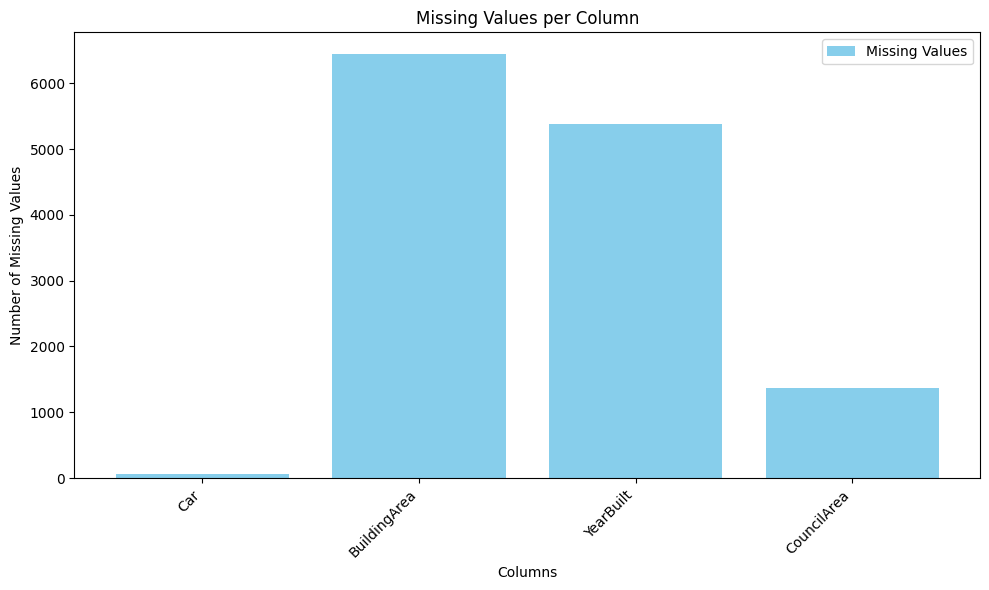

In [20]:
import matplotlib.pyplot as plt

missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0]

plt.figure(figsize=(10, 6))
plt.bar(missing_data.index, missing_data.values, color='skyblue', label='Missing Values')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.title('Missing Values per Column')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
numerical_cols_with_missing = df.select_dtypes(include=np.number).isnull().sum()
numerical_cols_with_missing = numerical_cols_with_missing[numerical_cols_with_missing > 0]
print("Numerical columns with missing values:\n", numerical_cols_with_missing)

Numerical columns with missing values:
 Car               62
BuildingArea    6450
YearBuilt       5375
dtype: int64


In [22]:
for col in ['Car', 'BuildingArea', 'YearBuilt']:
    df[col].fillna(df[col].median(), inplace=True)

print("Missing values after imputation for numerical columns:\n")
print(df[['Car', 'BuildingArea', 'YearBuilt']].isnull().sum())

Missing values after imputation for numerical columns:

Car             0
BuildingArea    0
YearBuilt       0
dtype: int64


/tmp/ipython-input-2421196273.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [23]:
for col in ['Car', 'BuildingArea', 'YearBuilt']:
    df[col] = df[col].fillna(df[col].median())

print("Missing values after imputation for numerical columns:\n")
print(df[['Car', 'BuildingArea', 'YearBuilt']].isnull().sum())

Missing values after imputation for numerical columns:

Car             0
BuildingArea    0
YearBuilt       0
dtype: int64


In [24]:
categorical_cols_with_missing = df.select_dtypes(include='object').isnull().sum()
categorical_cols_with_missing = categorical_cols_with_missing[categorical_cols_with_missing > 0]
print("Categorical columns with missing values:\n", categorical_cols_with_missing)

Categorical columns with missing values:
 CouncilArea    1369
dtype: int64


In [25]:
for col in categorical_cols_with_missing.index:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after imputation for categorical columns:")
print(df[categorical_cols_with_missing.index].isnull().sum())

Missing values after imputation for categorical columns:
CouncilArea    0
dtype: int64


In [26]:
missing_percentage = df.isnull().sum() / len(df) * 100
print("Percentage of missing values per column:\n", missing_percentage[missing_percentage > 0])

Percentage of missing values per column:
 Series([], dtype: float64)


In [27]:
print("Total missing values in the DataFrame after cleaning:")
print(df.isnull().sum().sum())

Total missing values in the DataFrame after cleaning:
0
